# Fase 2 — Análise Exploratória dos Dados (EDA)

**Projeto**: Mineração de Padrões Frequentes em Acidentes de Rodovias Federais  
**Grupo 18**: Erik Roberto Reis Neves, Gabriel Campos Prudente, Felipe Silva Fraga Damasceno  
**Disciplina**: Mineração de Dados — UFMG  

---

## Objetivos desta fase
1. Compreender a estrutura, distribuição e qualidade dos dados
2. Analisar a variável-alvo (gravidade dos acidentes) e seu desbalanceamento
3. Explorar padrões temporais, geográficos e categóricos
4. Identificar correlações entre variáveis categóricas (Cramér's V)
5. Formular hipóteses para a mineração de regras de associação

**Alinhamento CRISP-DM**: *Data Understanding*

## 2.0 Setup — Importações e Carregamento

Reutiliza a configuração e funções da Fase 1.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURAÇÕES DE VISUALIZAÇÃO
# ============================================================
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Paleta de cores para gravidade
CORES_GRAVIDADE = {
    'Sem Vítimas': '#2ecc71',
    'Com Vítimas Feridas': '#f39c12',
    'Com Vítimas Fatais': '#e74c3c',
    'Ignorado': '#95a5a6',
}

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports realizados com sucesso.')

Imports realizados com sucesso.


In [2]:
# ============================================================
# CONFIGURAÇÃO CENTRAL (replicada da Fase 1)
# ============================================================
DATA_DIR = Path('../data/')
OUTPUT_DIR = Path('../outputs/figuras/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'por_ocorrencia': {
        'file': 'datatran2026_agrupados_por_ocorrencia.csv',
        'granularity': 'ocorrência (1 linha = 1 acidente)',
        'id_col': 'id',
    },
    'por_pessoa': {
        'file': 'acidentes2026_agrupados_por_pessoa.csv',
        'granularity': 'pessoa (1 linha = 1 pessoa envolvida)',
        'id_col': 'pesid',
    },
    'todas_causas': {
        'file': 'acidentes2026_todas_causas_tipos.csv',
        'granularity': 'causa x pessoa (explode multicausa)',
        'id_col': 'pesid',
    },
}

# >>> DATASET ATIVO <<<
ACTIVE_DATASET = 'por_ocorrencia'
FILTRO_UF = 'MG'
SEP = ';'
ENCODING = 'latin-1'

# Colunas categóricas comuns para análise
COLUNAS_CATEGORICAS = [
    'dia_semana', 'causa_acidente', 'tipo_acidente',
    'classificacao_acidente', 'fase_dia', 'sentido_via',
    'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
]

COLUNAS_NUMERICAS = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'feridos', 'veiculos']
COLUNAS_TEMPORAIS = ['data_inversa', 'horario']

In [3]:
# ============================================================
# CARREGAMENTO
# ============================================================
info = DATASETS[ACTIVE_DATASET]
path = DATA_DIR / info['file']
df = pd.read_csv(path, sep=SEP, encoding=ENCODING, low_memory=False)

if FILTRO_UF:
    df = df[df['uf'] == FILTRO_UF].copy()

print(f'Dataset: {info["file"]}')
print(f'Granularidade: {info["granularity"]}')
print(f'Filtro UF: {FILTRO_UF}')
print(f'Registros: {len(df):,}')
print(f'Colunas: {df.shape[1]}')

Dataset: datatran2026_agrupados_por_ocorrencia.csv
Granularidade: ocorrência (1 linha = 1 acidente)
Filtro UF: MG
Registros: 2,985
Colunas: 30


---

## 2.1 Visão Geral do Dataset

In [4]:
# Tipos de dados e valores não-nulos
df.info()

<class 'pandas.DataFrame'>
Index: 2985 entries, 1 to 23474
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      2985 non-null   int64
 1   data_inversa            2985 non-null   str  
 2   dia_semana              2985 non-null   str  
 3   horario                 2985 non-null   str  
 4   uf                      2985 non-null   str  
 5   br                      2985 non-null   int64
 6   km                      2985 non-null   str  
 7   municipio               2985 non-null   str  
 8   causa_acidente          2985 non-null   str  
 9   tipo_acidente           2985 non-null   str  
 10  classificacao_acidente  2985 non-null   str  
 11  fase_dia                2985 non-null   str  
 12  sentido_via             2985 non-null   str  
 13  condicao_metereologica  2985 non-null   str  
 14  tipo_pista              2985 non-null   str  
 15  tracado_via             2985 non-nul

In [5]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,id,br,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos
count,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000,2985.0000
mean,755718.1534,226.5273,2.6737,0.0901,0.9970,0.2814,0.9920,0.4117,1.2784,1.9367
std,7572.6977,144.1168,2.7771,0.3791,1.6202,0.7239,1.7940,0.8177,1.8434,1.1393
min,742888.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
25%,749023.0000,50.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
50%,755988.0000,262.0000,2.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,2.0000
75%,762119.0000,381.0000,3.0000,0.0000,1.0000,0.0000,1.0000,1.0000,2.0000,2.0000
max,772009.0000,459.0000,59.0000,6.0000,40.0000,23.0000,39.0000,13.0000,47.0000,14.0000


In [6]:
# Tabela de resumo completa por coluna
resumo = pd.DataFrame({
    'tipo': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unicos': df.nunique(),
    'exemplo': df.iloc[0],
})
resumo = resumo.sort_values('nulos_%', ascending=False)
print(f'Total de registros: {len(df):,}')
print(f'Colunas com valores nulos: {(resumo["nulos"] > 0).sum()}')
resumo

Total de registros: 2,985
Colunas com valores nulos: 0


,tipo,nulos,nulos_%,unicos,exemplo
id,int64,0,0.0000,2985,742942
data_inversa,str,0,0.0000,120,2026-01-01
dia_semana,str,0,0.0000,7,quinta-feira
horario,str,0,0.0000,461,06:40:00
uf,str,0,0.0000,1,MG
br,int64,0,0.0000,15,262
km,str,0,0.0000,1860,"146,1"
municipio,str,0,0.0000,203,RIO CASCA
causa_acidente,str,0,0.0000,57,Condutor Dormindo
tipo_acidente,str,0,0.0000,16,Colisão frontal


In [7]:
# Visualização de valores nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=True)

if len(nulos) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nulos) * 0.5)))
    nulos.plot(kind='barh', color='#e74c3c', ax=ax)
    ax.set_xlabel('Quantidade de valores nulos')
    ax.set_title('Valores Nulos por Coluna')
    for i, v in enumerate(nulos):
        ax.text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'nulos_por_coluna.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma coluna possui valores nulos.')

Nenhuma coluna possui valores nulos.


---

## 2.2 Distribuição da Variável-Alvo: Gravidade do Acidente

A coluna `classificacao_acidente` é a variável central do projeto. Precisamos entender sua distribuição e o desbalanceamento entre classes.

=== Distribuição da Classificação do Acidente ===
  Com Vítimas Feridas: 2,368 (79.3%)
  Sem Vítimas: 406 (13.6%)
  Com Vítimas Fatais: 211 (7.1%)


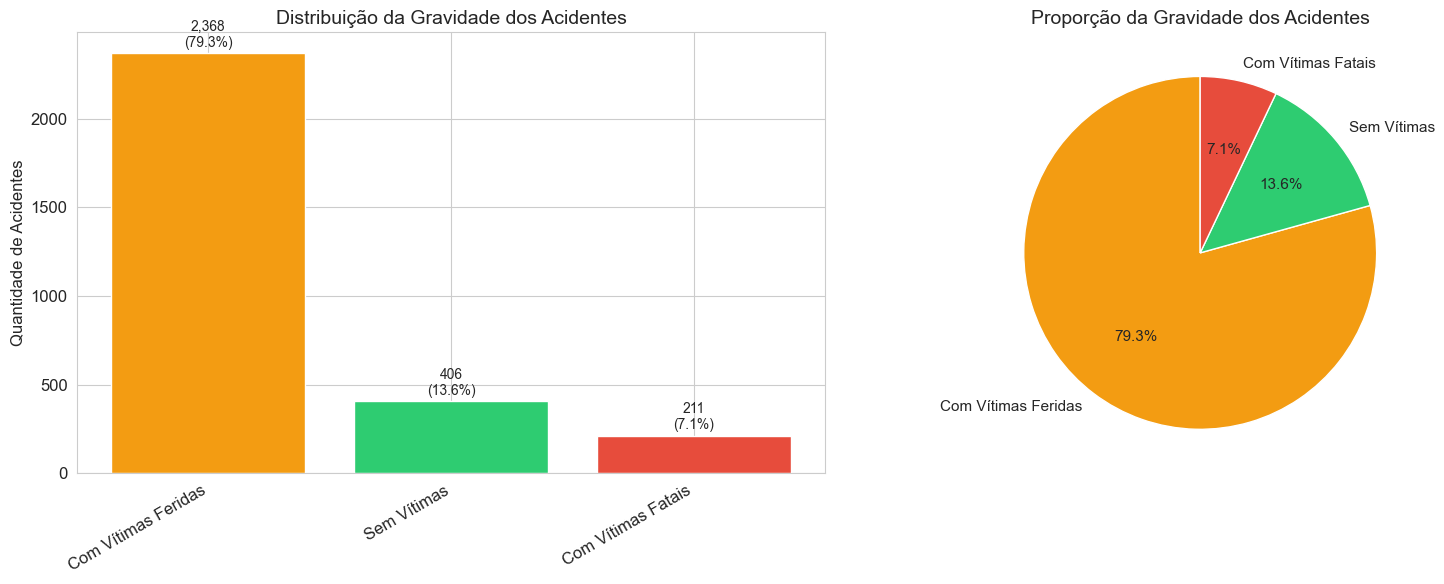

In [8]:
# Distribuição da gravidade
gravidade = df['classificacao_acidente'].fillna('Ignorado').value_counts()
gravidade_pct = df['classificacao_acidente'].fillna('Ignorado').value_counts(normalize=True) * 100

print('=== Distribuição da Classificação do Acidente ===')
for cat in gravidade.index:
    print(f'  {cat}: {gravidade[cat]:,} ({gravidade_pct[cat]:.1f}%)')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
cores = [CORES_GRAVIDADE.get(x, '#95a5a6') for x in gravidade.index]
bars = axes[0].bar(range(len(gravidade)), gravidade.values, color=cores)
axes[0].set_xticks(range(len(gravidade)))
axes[0].set_xticklabels(gravidade.index, rotation=30, ha='right')
axes[0].set_ylabel('Quantidade de Acidentes')
axes[0].set_title('Distribuição da Gravidade dos Acidentes')
for bar, val, pct in zip(bars, gravidade.values, gravidade_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(gravidade.values, labels=gravidade.index, colors=cores,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporção da Gravidade dos Acidentes')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribuicao_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 2.3 Análise Temporal

In [9]:
# Preparação: converter data e extrair componentes temporais
df['data_inversa'] = pd.to_datetime(df['data_inversa'], errors='coerce')
df['mes'] = df['data_inversa'].dt.month
df['semana_ano'] = df['data_inversa'].dt.isocalendar().week.astype(int)
df['hora'] = pd.to_datetime(df['horario'], format='%H:%M:%S', errors='coerce').dt.hour

# Criar faixa horária
def classificar_faixa_horaria(h):
    if pd.isna(h):
        return 'N/A'
    if h < 6:
        return 'Madrugada (00-06)'
    elif h < 12:
        return 'Manhã (06-12)'
    elif h < 18:
        return 'Tarde (12-18)'
    else:
        return 'Noite (18-24)'

df['faixa_horaria'] = df['hora'].apply(classificar_faixa_horaria)

# Criar flag de fim de semana
df['fim_de_semana'] = df['dia_semana'].isin(['sábado', 'domingo']).astype(str)

print('Variáveis temporais criadas com sucesso.')
print(f'  Meses encontrados: {sorted(df["mes"].dropna().unique())}')
print(f'  Faixas horárias: {df["faixa_horaria"].value_counts().to_dict()}')

Variáveis temporais criadas com sucesso.
  Meses encontrados: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
  Faixas horárias: {'Tarde (12-18)': 1006, 'Manhã (06-12)': 805, 'Noite (18-24)': 798, 'Madrugada (00-06)': 376}


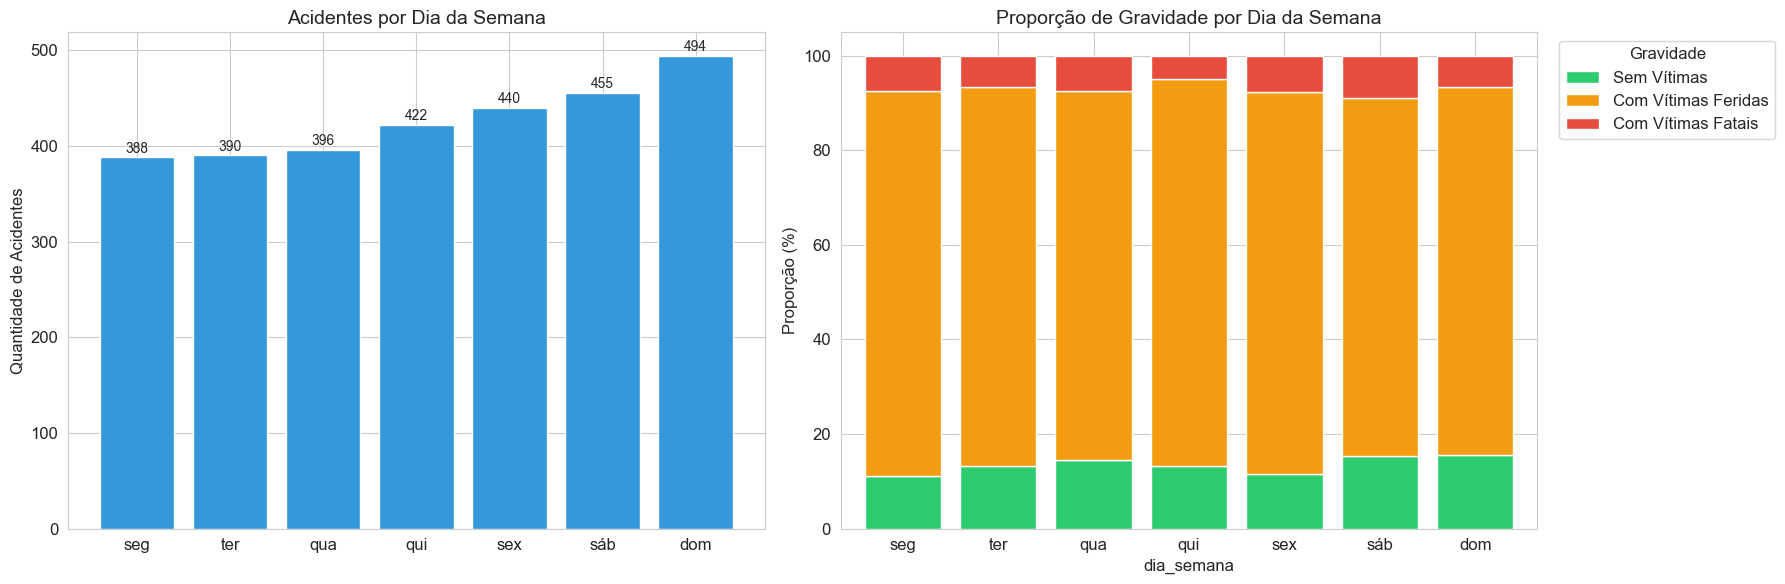

In [10]:
# 2.3.1 — Acidentes por dia da semana
ordem_dias = ['segunda-feira', 'terça-feira', 'quarta-feira',
              'quinta-feira', 'sexta-feira', 'sábado', 'domingo']
# Filtrar apenas dias que existem no dataset
ordem_dias = [d for d in ordem_dias if d in df['dia_semana'].values]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Total por dia da semana
dia_counts = df['dia_semana'].value_counts().reindex(ordem_dias)
axes[0].bar(range(len(dia_counts)), dia_counts.values, color='#3498db')
axes[0].set_xticks(range(len(dia_counts)))
axes[0].set_xticklabels([d[:3] for d in dia_counts.index], rotation=0)
axes[0].set_ylabel('Quantidade de Acidentes')
axes[0].set_title('Acidentes por Dia da Semana')
for i, v in enumerate(dia_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Gravidade por dia da semana (stacked)
ct_dia_grav = pd.crosstab(df['dia_semana'], df['classificacao_acidente'].fillna('Ignorado'),
                          normalize='index') * 100
ct_dia_grav = ct_dia_grav.reindex(ordem_dias)
cols_ordered = ['Sem Vítimas', 'Com Vítimas Feridas', 'Com Vítimas Fatais', 'Ignorado']
cols_ordered = [c for c in cols_ordered if c in ct_dia_grav.columns]
ct_dia_grav = ct_dia_grav[cols_ordered]
cores_stack = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_ordered]

ct_dia_grav.plot(kind='bar', stacked=True, ax=axes[1], color=cores_stack, width=0.8)
axes[1].set_ylabel('Proporção (%)')
axes[1].set_title('Proporção de Gravidade por Dia da Semana')
axes[1].set_xticklabels([d[:3] for d in ordem_dias], rotation=0)
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'acidentes_dia_semana.png', dpi=300, bbox_inches='tight')
plt.show()

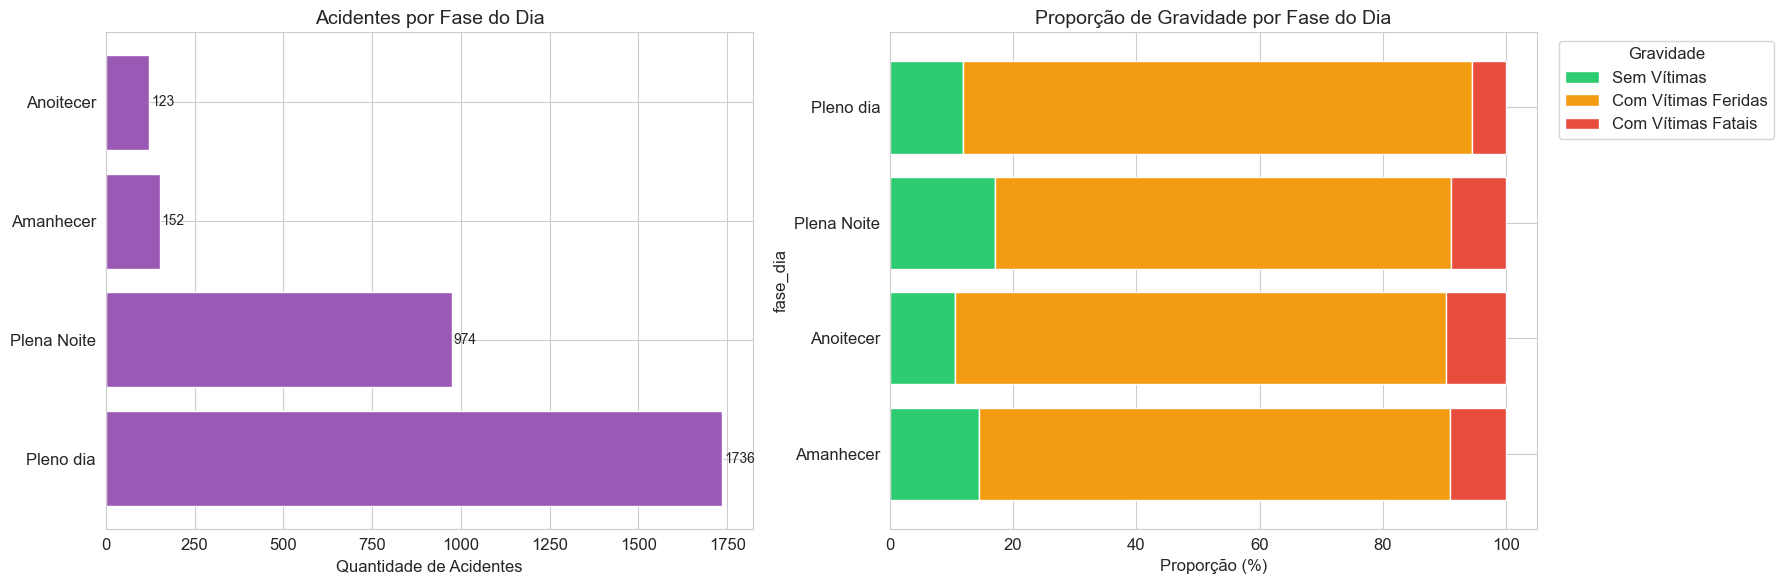

In [11]:
# 2.3.2 — Acidentes por fase do dia
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fase_counts = df['fase_dia'].value_counts()
axes[0].barh(range(len(fase_counts)), fase_counts.values, color='#9b59b6')
axes[0].set_yticks(range(len(fase_counts)))
axes[0].set_yticklabels(fase_counts.index)
axes[0].set_xlabel('Quantidade de Acidentes')
axes[0].set_title('Acidentes por Fase do Dia')
for i, v in enumerate(fase_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Gravidade por fase do dia
ct_fase_grav = pd.crosstab(df['fase_dia'], df['classificacao_acidente'].fillna('Ignorado'),
                           normalize='index') * 100
cols_ordered_filt = [c for c in cols_ordered if c in ct_fase_grav.columns]
cores_stack_filt = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_ordered_filt]
ct_fase_grav[cols_ordered_filt].plot(kind='barh', stacked=True, ax=axes[1],
                                     color=cores_stack_filt, width=0.8)
axes[1].set_xlabel('Proporção (%)')
axes[1].set_title('Proporção de Gravidade por Fase do Dia')
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'acidentes_fase_dia.png', dpi=300, bbox_inches='tight')
plt.show()

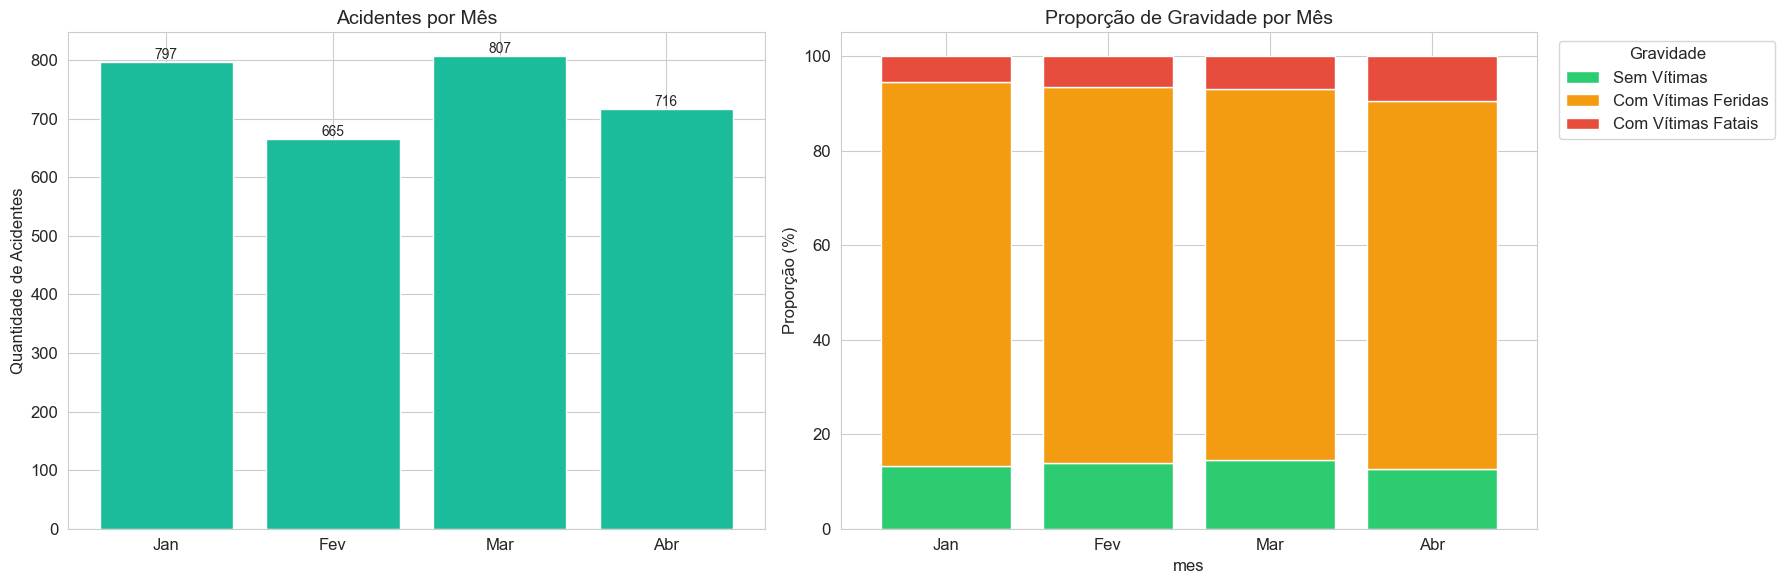

In [12]:
# 2.3.3 — Acidentes por mês
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

meses_nome = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
              7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

mes_counts = df['mes'].value_counts().sort_index()
axes[0].bar(mes_counts.index, mes_counts.values, color='#1abc9c')
axes[0].set_xticks(mes_counts.index)
axes[0].set_xticklabels([meses_nome.get(m, m) for m in mes_counts.index])
axes[0].set_ylabel('Quantidade de Acidentes')
axes[0].set_title('Acidentes por Mês')
for x, v in zip(mes_counts.index, mes_counts.values):
    axes[0].text(x, v + 5, str(v), ha='center', fontsize=10)

# Gravidade por mês
ct_mes_grav = pd.crosstab(df['mes'], df['classificacao_acidente'].fillna('Ignorado'),
                          normalize='index') * 100
cols_ordered_filt2 = [c for c in cols_ordered if c in ct_mes_grav.columns]
cores_stack_filt2 = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_ordered_filt2]
ct_mes_grav[cols_ordered_filt2].plot(kind='bar', stacked=True, ax=axes[1],
                                     color=cores_stack_filt2, width=0.8)
axes[1].set_ylabel('Proporção (%)')
axes[1].set_title('Proporção de Gravidade por Mês')
axes[1].set_xticklabels([meses_nome.get(m, m) for m in ct_mes_grav.index], rotation=0)
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'acidentes_mes.png', dpi=300, bbox_inches='tight')
plt.show()

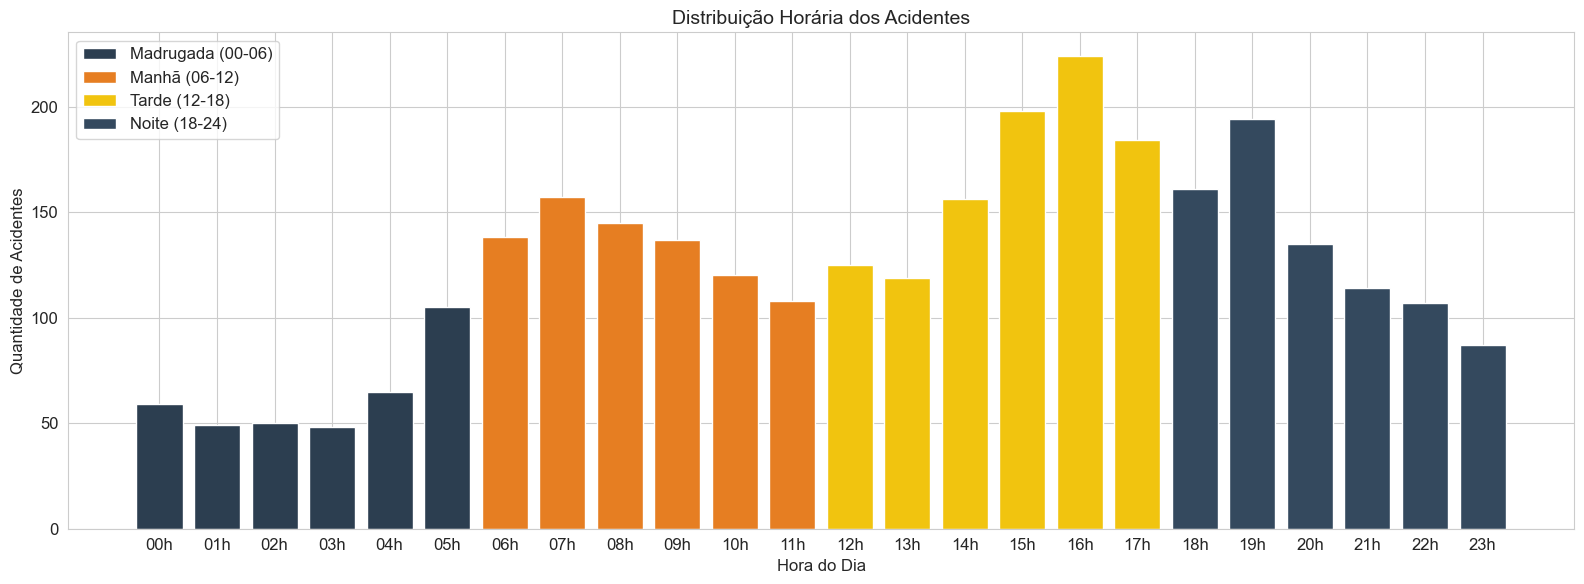

In [13]:
# 2.3.4 — Distribuição horária dos acidentes
fig, ax = plt.subplots(figsize=(16, 6))

hora_counts = df['hora'].dropna().astype(int).value_counts().sort_index()

# Colorir por faixa horária
cores_hora = []
for h in hora_counts.index:
    if h < 6:
        cores_hora.append('#2c3e50')   # Madrugada
    elif h < 12:
        cores_hora.append('#e67e22')   # Manhã
    elif h < 18:
        cores_hora.append('#f1c40f')   # Tarde
    else:
        cores_hora.append('#34495e')   # Noite

ax.bar(hora_counts.index, hora_counts.values, color=cores_hora, edgecolor='white')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Quantidade de Acidentes')
ax.set_title('Distribuição Horária dos Acidentes')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}h' for h in range(24)])

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c3e50', label='Madrugada (00-06)'),
    Patch(facecolor='#e67e22', label='Manhã (06-12)'),
    Patch(facecolor='#f1c40f', label='Tarde (12-18)'),
    Patch(facecolor='#34495e', label='Noite (18-24)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribuicao_horaria.png', dpi=300, bbox_inches='tight')
plt.show()

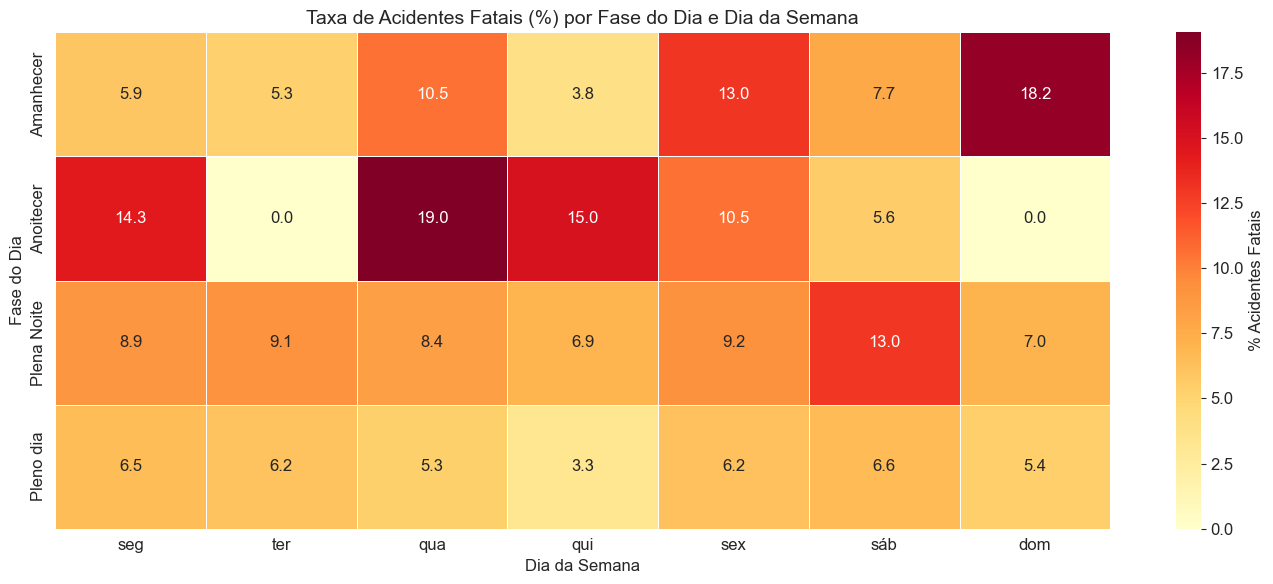

In [14]:
# 2.3.5 — Heatmap: Gravidade x Dia da Semana x Fase do Dia
# Taxa de acidentes fatais por combinação dia x fase
df['is_fatal'] = (df['classificacao_acidente'] == 'Com Vítimas Fatais').astype(int)

ct_heatmap = pd.pivot_table(
    df, values='is_fatal', index='fase_dia', columns='dia_semana',
    aggfunc='mean'
) * 100  # Converter para percentual

# Reordenar colunas por dia da semana
cols_dias = [d for d in ordem_dias if d in ct_heatmap.columns]
ct_heatmap = ct_heatmap[cols_dias]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% Acidentes Fatais'})
ax.set_title('Taxa de Acidentes Fatais (%) por Fase do Dia e Dia da Semana')
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Fase do Dia')
ax.set_xticklabels([d[:3] for d in cols_dias], rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

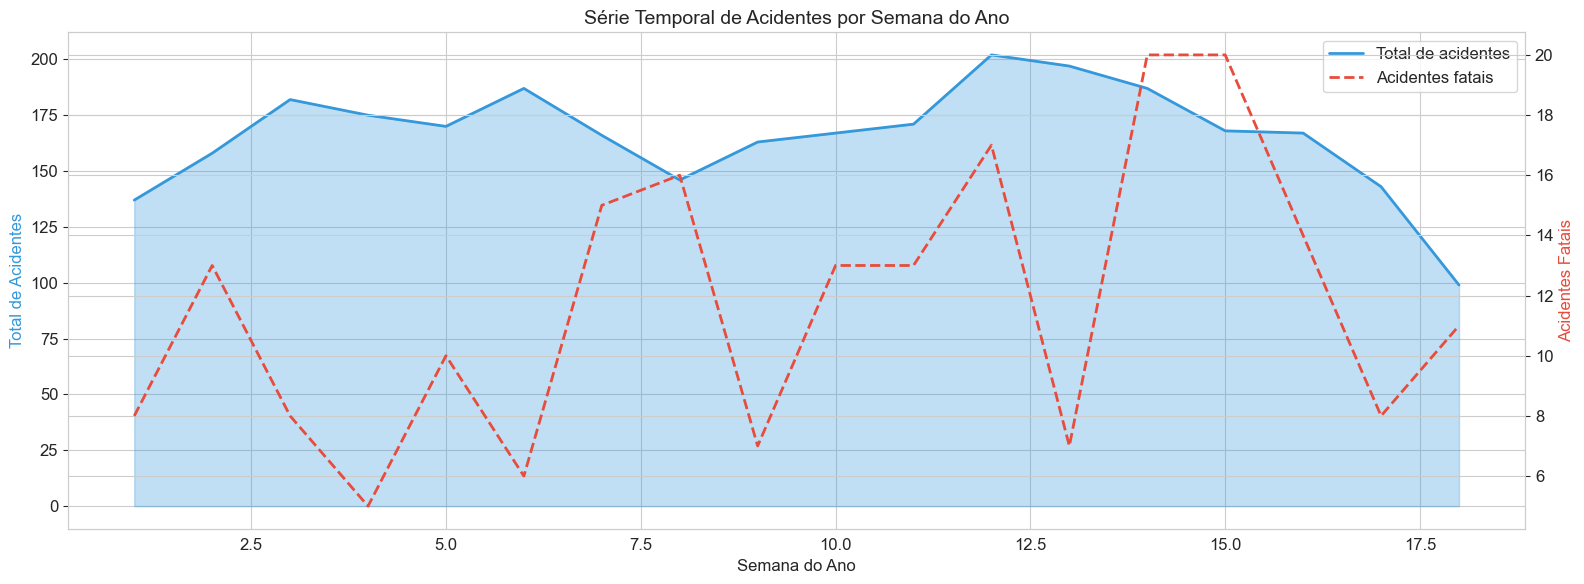

In [15]:
# 2.3.6 — Série temporal: acidentes por semana
serie_semanal = df.groupby('semana_ano').agg(
    total=('id', 'count'),
    fatais=('is_fatal', 'sum'),
    mortos_total=('mortos', 'sum'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.fill_between(serie_semanal['semana_ano'], serie_semanal['total'],
                 alpha=0.3, color='#3498db')
ax1.plot(serie_semanal['semana_ano'], serie_semanal['total'],
         color='#3498db', linewidth=2, label='Total de acidentes')
ax1.set_xlabel('Semana do Ano')
ax1.set_ylabel('Total de Acidentes', color='#3498db')

ax2 = ax1.twinx()
ax2.plot(serie_semanal['semana_ano'], serie_semanal['fatais'],
         color='#e74c3c', linewidth=2, linestyle='--', label='Acidentes fatais')
ax2.set_ylabel('Acidentes Fatais', color='#e74c3c')

ax1.set_title('Série Temporal de Acidentes por Semana do Ano')

# Combinar legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'serie_temporal_semanal.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 2.4 Análise Geográfica

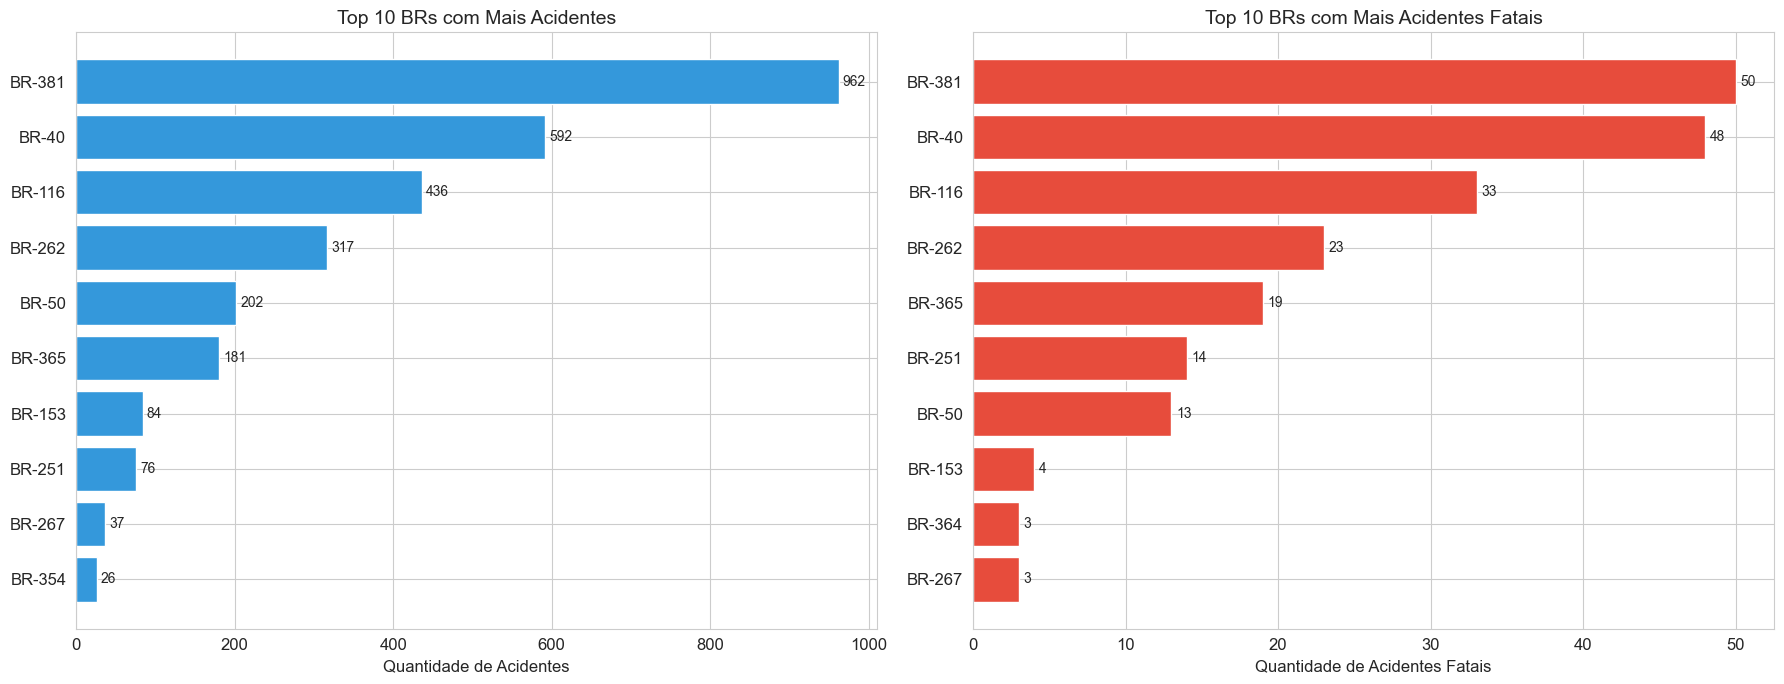

In [16]:
# 2.4.1 — Top 10 BRs com mais acidentes
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Total de acidentes por BR
top_brs = df['br'].value_counts().head(10)
axes[0].barh(range(len(top_brs)), top_brs.values, color='#3498db')
axes[0].set_yticks(range(len(top_brs)))
axes[0].set_yticklabels([f'BR-{int(b)}' for b in top_brs.index])
axes[0].set_xlabel('Quantidade de Acidentes')
axes[0].set_title('Top 10 BRs com Mais Acidentes')
axes[0].invert_yaxis()
for i, v in enumerate(top_brs.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Top 10 BRs com mais acidentes FATAIS
fatais_por_br = df[df['is_fatal'] == 1]['br'].value_counts().head(10)
axes[1].barh(range(len(fatais_por_br)), fatais_por_br.values, color='#e74c3c')
axes[1].set_yticks(range(len(fatais_por_br)))
axes[1].set_yticklabels([f'BR-{int(b)}' for b in fatais_por_br.index])
axes[1].set_xlabel('Quantidade de Acidentes Fatais')
axes[1].set_title('Top 10 BRs com Mais Acidentes Fatais')
axes[1].invert_yaxis()
for i, v in enumerate(fatais_por_br.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_brs.png', dpi=300, bbox_inches='tight')
plt.show()

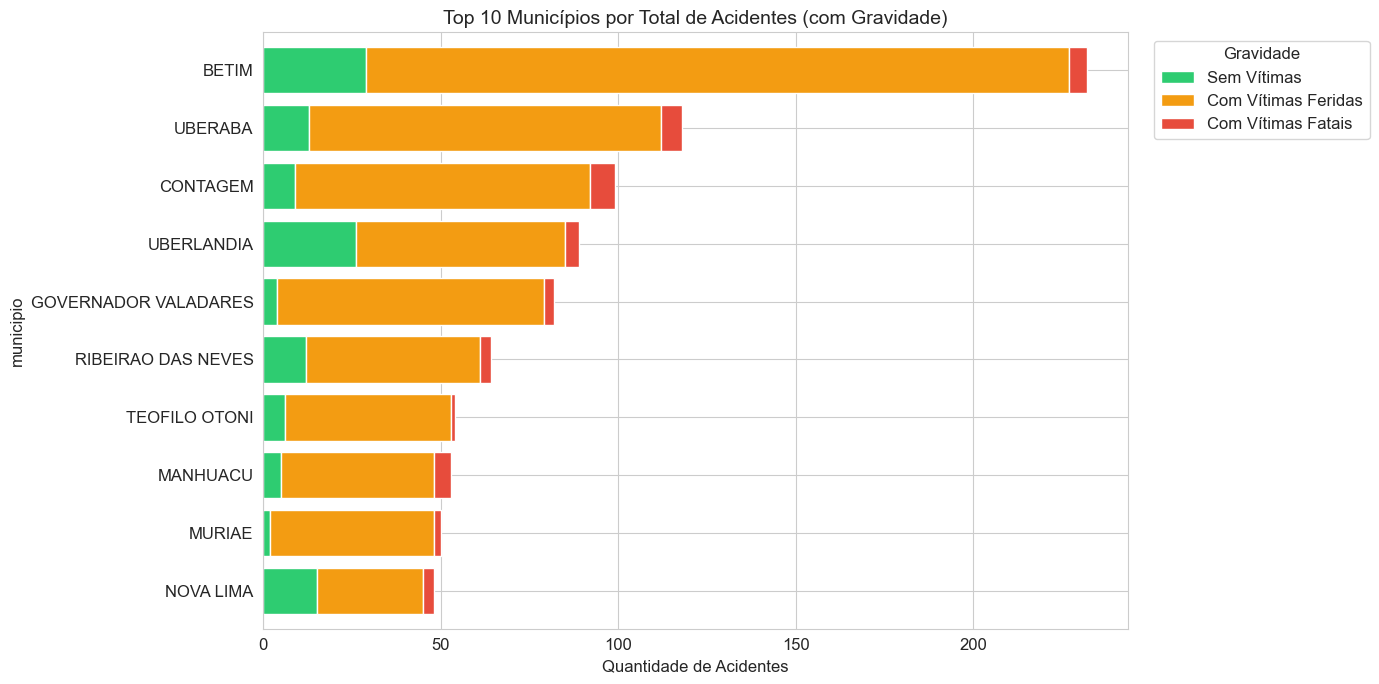

In [17]:
# 2.4.2 — Top 10 Municípios
fig, ax = plt.subplots(figsize=(14, 7))

# Crosstab município x gravidade (top 10 por total)
top_municipios = df['municipio'].value_counts().head(10).index
df_top_mun = df[df['municipio'].isin(top_municipios)]

ct_mun = pd.crosstab(df_top_mun['municipio'], df_top_mun['classificacao_acidente'].fillna('Ignorado'))
cols_mun = [c for c in cols_ordered if c in ct_mun.columns]
cores_mun = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_mun]
ct_mun = ct_mun[cols_mun]
ct_mun = ct_mun.loc[ct_mun.sum(axis=1).sort_values(ascending=True).index]

ct_mun.plot(kind='barh', stacked=True, ax=ax, color=cores_mun, width=0.8)
ax.set_xlabel('Quantidade de Acidentes')
ax.set_title('Top 10 Municípios por Total de Acidentes (com Gravidade)')
ax.legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_municipios.png', dpi=300, bbox_inches='tight')
plt.show()

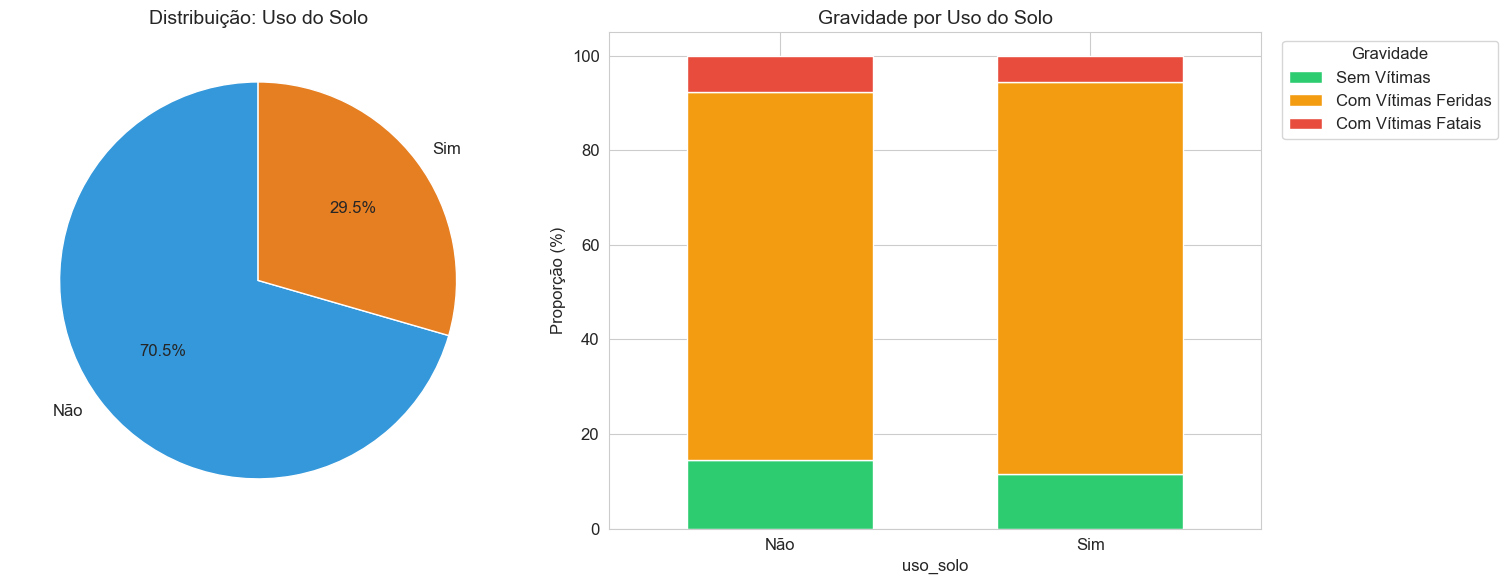

In [18]:
# 2.4.3 — Uso do solo (Urbano vs Rural)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

uso_counts = df['uso_solo'].value_counts()
axes[0].pie(uso_counts.values, labels=uso_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#3498db', '#e67e22'],
            textprops={'fontsize': 12})
axes[0].set_title('Distribuição: Uso do Solo')

# Gravidade por uso do solo
ct_uso = pd.crosstab(df['uso_solo'], df['classificacao_acidente'].fillna('Ignorado'),
                     normalize='index') * 100
cols_uso = [c for c in cols_ordered if c in ct_uso.columns]
cores_uso = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_uso]
ct_uso[cols_uso].plot(kind='bar', stacked=True, ax=axes[1], color=cores_uso, width=0.6)
axes[1].set_ylabel('Proporção (%)')
axes[1].set_title('Gravidade por Uso do Solo')
axes[1].set_xticklabels(ct_uso.index, rotation=0)
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uso_solo.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 2.4.4 — Mapa de calor geográfico (scatter com lat/long)
df_geo = df.dropna(subset=['latitude', 'longitude']).copy()

# Converter latitude/longitude (pode usar vírgula como decimal)
for col in ['latitude', 'longitude']:
    if df_geo[col].dtype == object:
        df_geo[col] = df_geo[col].str.replace(',', '.').astype(float)
    else:
        df_geo[col] = df_geo[col].astype(float)

fig, ax = plt.subplots(figsize=(12, 14))

# Plotar pontos coloridos por gravidade
for grav, cor in CORES_GRAVIDADE.items():
    mask = df_geo['classificacao_acidente'] == grav
    if mask.sum() > 0:
        ax.scatter(
            df_geo.loc[mask, 'longitude'],
            df_geo.loc[mask, 'latitude'],
            c=cor, label=grav, alpha=0.4, s=10, edgecolors='none'
        )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Mapa de Acidentes — {FILTRO_UF or "Brasil"}')
ax.legend(title='Gravidade', markerscale=3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mapa_calor_geografico.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Registros com coordenadas válidas: {len(df_geo):,} de {len(df):,}')

ValueError: could not convert string to float: '-20,0240733'

---

## 2.5 Análise das Variáveis Categóricas

Para cada variável categórica relevante, analisamos a distribuição e o cruzamento com a gravidade.

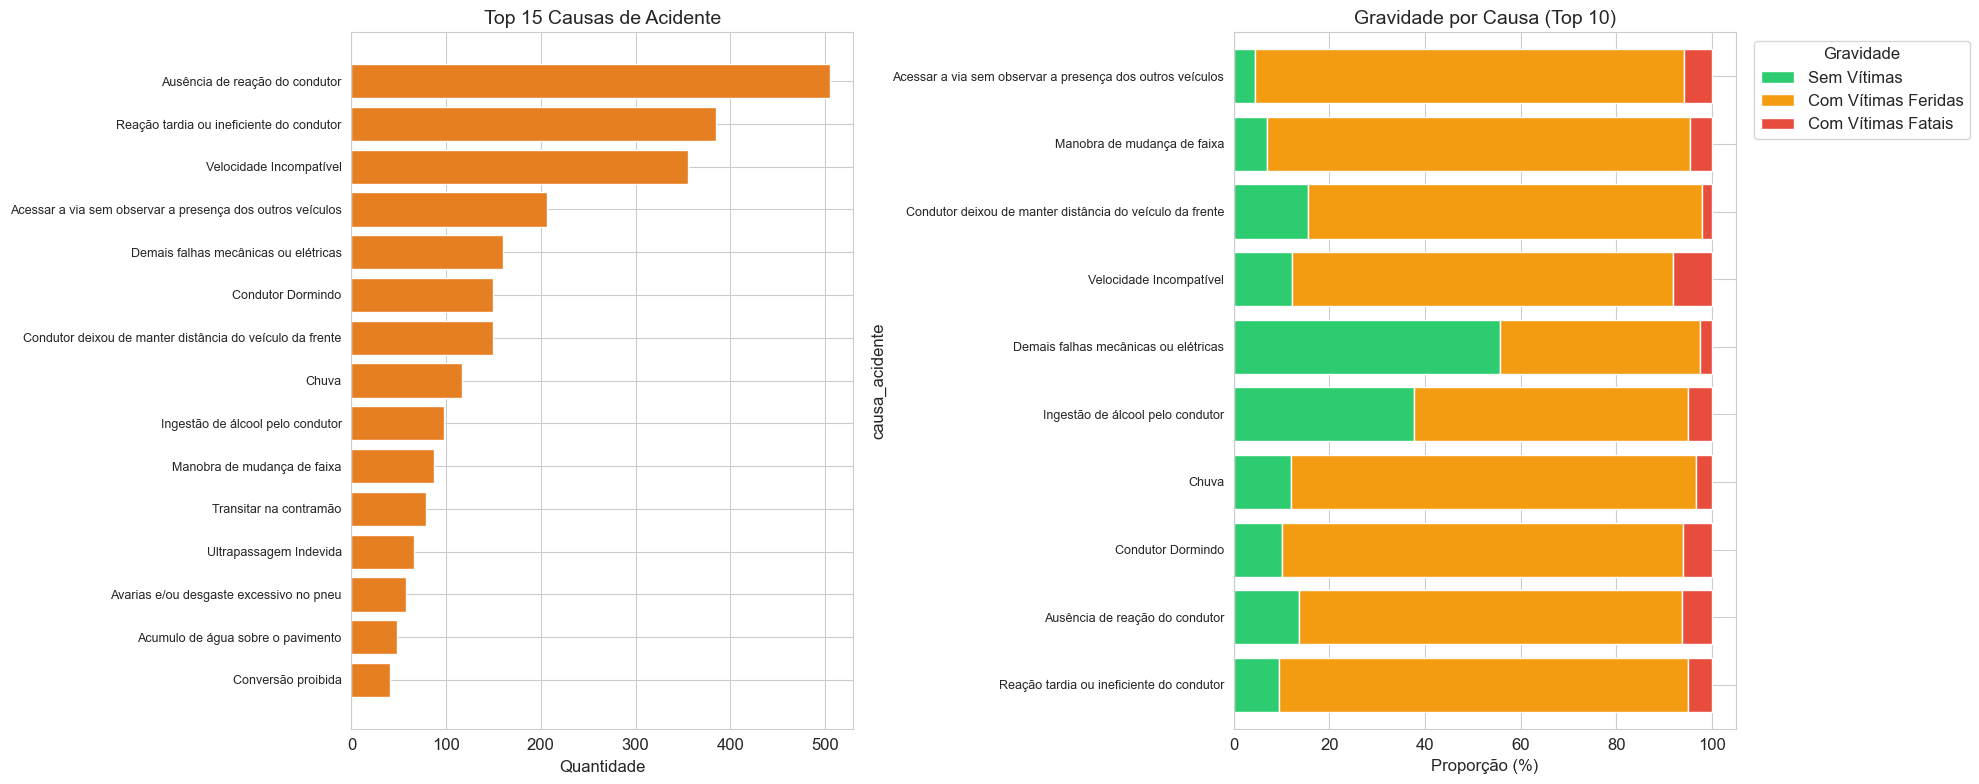

In [20]:
# 2.5.1 — Top causas de acidente + cruzamento com gravidade
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top 15 causas
top_causas = df['causa_acidente'].value_counts().head(15)
axes[0].barh(range(len(top_causas)), top_causas.values, color='#e67e22')
axes[0].set_yticks(range(len(top_causas)))
axes[0].set_yticklabels(top_causas.index, fontsize=9)
axes[0].set_xlabel('Quantidade')
axes[0].set_title('Top 15 Causas de Acidente')
axes[0].invert_yaxis()

# Cruzamento: top 10 causas x gravidade (normalizado por causa)
top10_causas = df['causa_acidente'].value_counts().head(10).index
df_top_causa = df[df['causa_acidente'].isin(top10_causas)]
ct_causa = pd.crosstab(df_top_causa['causa_acidente'],
                       df_top_causa['classificacao_acidente'].fillna('Ignorado'),
                       normalize='index') * 100
cols_causa = [c for c in cols_ordered if c in ct_causa.columns]
cores_causa = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_causa]
ct_causa = ct_causa[cols_causa]
ct_causa = ct_causa.loc[ct_causa.sum(axis=1).sort_values(ascending=True).index]

ct_causa.plot(kind='barh', stacked=True, ax=axes[1], color=cores_causa, width=0.8)
axes[1].set_xlabel('Proporção (%)')
axes[1].set_title('Gravidade por Causa (Top 10)')
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_causas_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

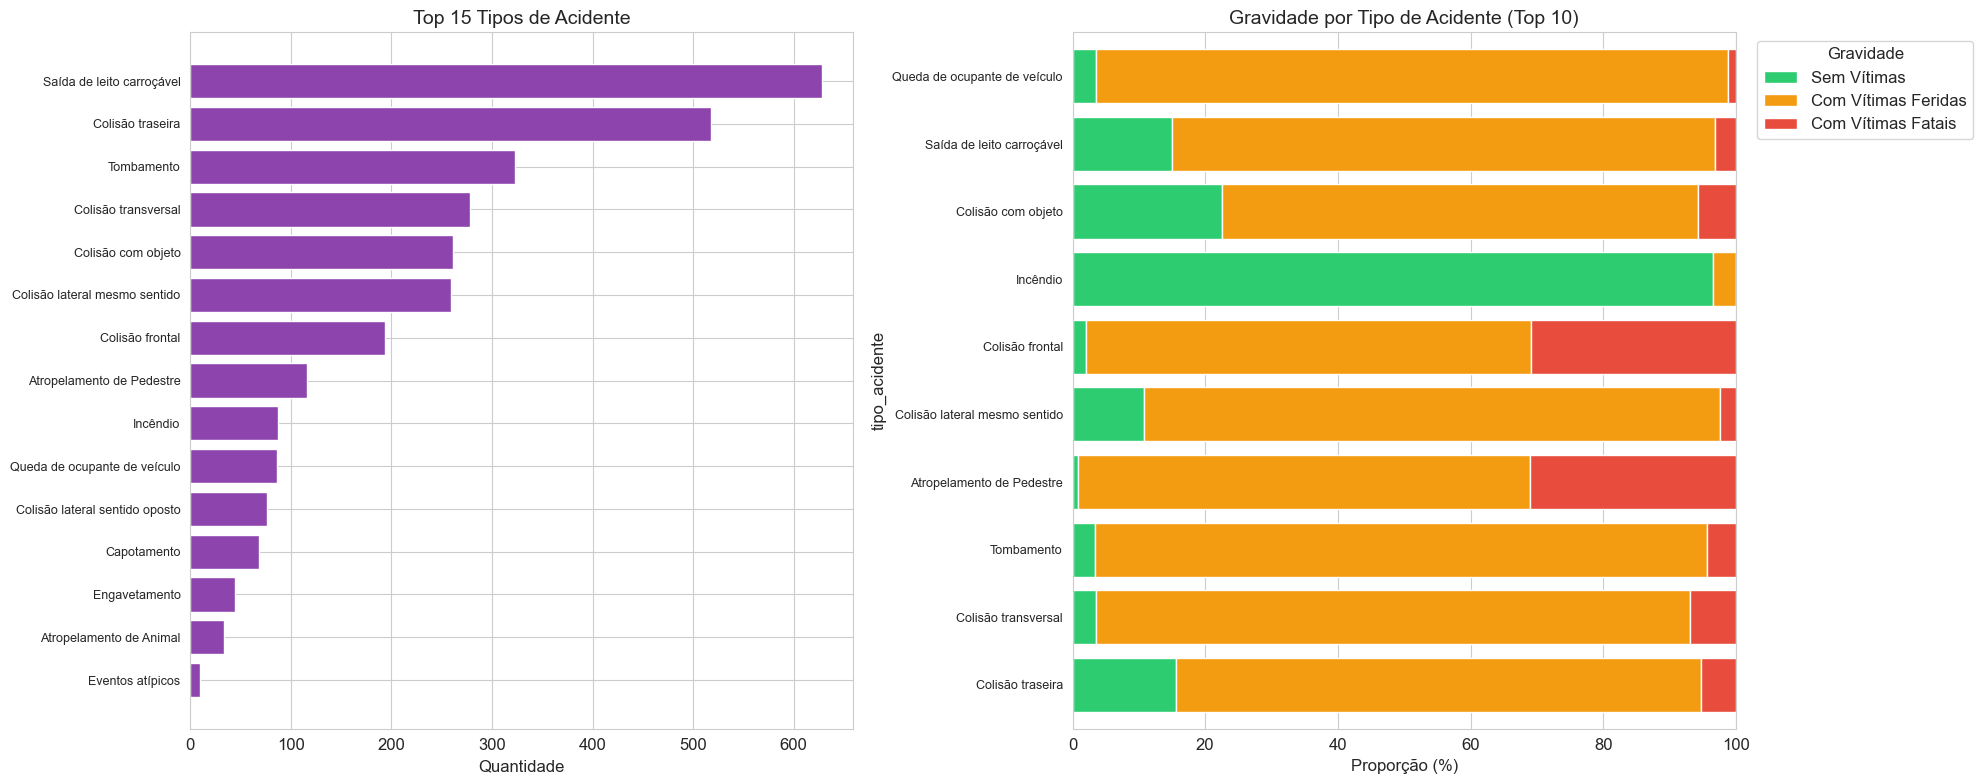

In [21]:
# 2.5.2 — Tipo de acidente + cruzamento com gravidade
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

tipo_counts = df['tipo_acidente'].value_counts().head(15)
axes[0].barh(range(len(tipo_counts)), tipo_counts.values, color='#8e44ad')
axes[0].set_yticks(range(len(tipo_counts)))
axes[0].set_yticklabels(tipo_counts.index, fontsize=9)
axes[0].set_xlabel('Quantidade')
axes[0].set_title('Top 15 Tipos de Acidente')
axes[0].invert_yaxis()

# Cruzamento com gravidade
top10_tipos = df['tipo_acidente'].value_counts().head(10).index
df_top_tipo = df[df['tipo_acidente'].isin(top10_tipos)]
ct_tipo = pd.crosstab(df_top_tipo['tipo_acidente'],
                      df_top_tipo['classificacao_acidente'].fillna('Ignorado'),
                      normalize='index') * 100
cols_tipo = [c for c in cols_ordered if c in ct_tipo.columns]
cores_tipo = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_tipo]
ct_tipo = ct_tipo[cols_tipo]
ct_tipo = ct_tipo.loc[ct_tipo.sum(axis=1).sort_values(ascending=True).index]

ct_tipo.plot(kind='barh', stacked=True, ax=axes[1], color=cores_tipo, width=0.8)
axes[1].set_xlabel('Proporção (%)')
axes[1].set_title('Gravidade por Tipo de Acidente (Top 10)')
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tipos_acidente_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

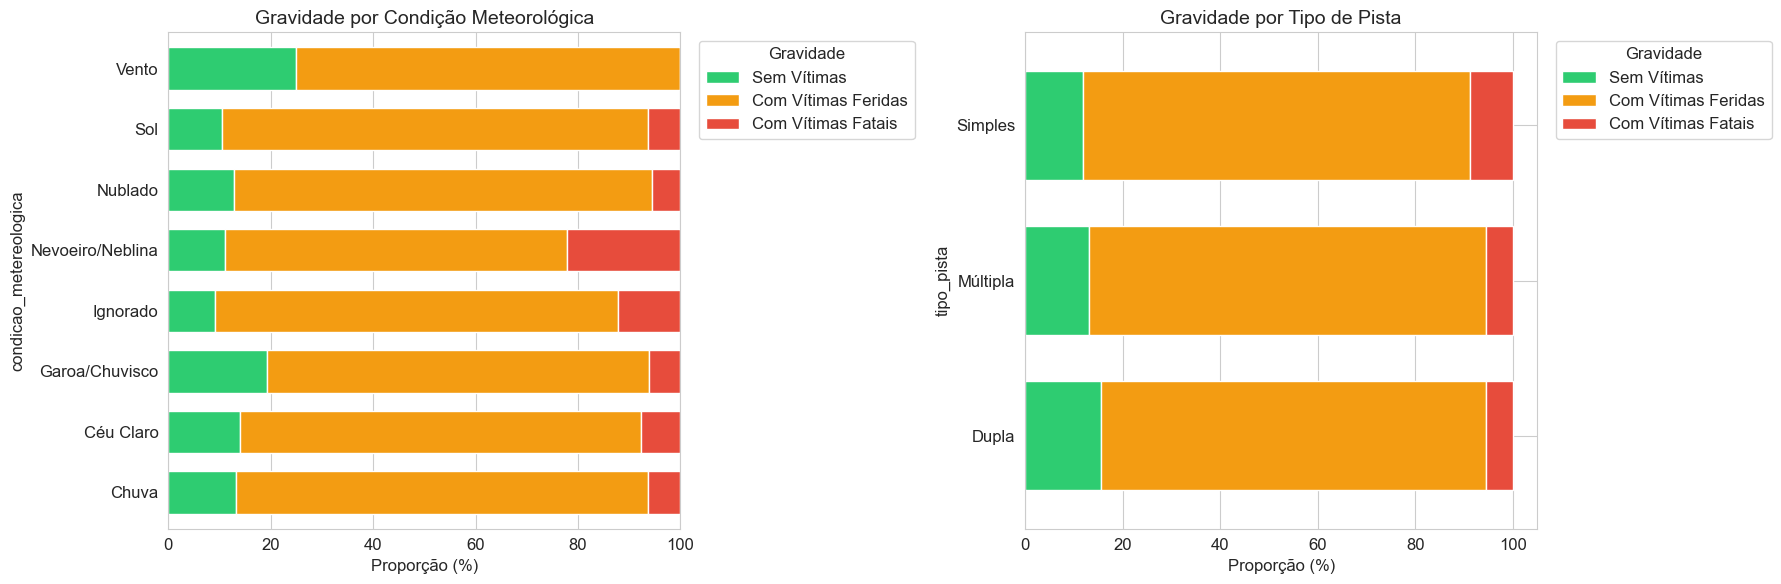

In [22]:
# 2.5.3 — Condição meteorológica e tipo de pista
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Condição meteorológica
ct_meteo = pd.crosstab(df['condicao_metereologica'],
                       df['classificacao_acidente'].fillna('Ignorado'),
                       normalize='index') * 100
cols_meteo = [c for c in cols_ordered if c in ct_meteo.columns]
cores_meteo = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_meteo]
ct_meteo[cols_meteo].plot(kind='barh', stacked=True, ax=axes[0], color=cores_meteo, width=0.7)
axes[0].set_xlabel('Proporção (%)')
axes[0].set_title('Gravidade por Condição Meteorológica')
axes[0].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

# Tipo de pista
ct_pista = pd.crosstab(df['tipo_pista'],
                       df['classificacao_acidente'].fillna('Ignorado'),
                       normalize='index') * 100
cols_pista = [c for c in cols_ordered if c in ct_pista.columns]
cores_pista = [CORES_GRAVIDADE.get(c, '#95a5a6') for c in cols_pista]
ct_pista[cols_pista].plot(kind='barh', stacked=True, ax=axes[1], color=cores_pista, width=0.7)
axes[1].set_xlabel('Proporção (%)')
axes[1].set_title('Gravidade por Tipo de Pista')
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'meteo_pista_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# 2.5.4 — Categorias raras (< 1%)
print('=== CATEGORIAS RARAS (< 1% dos registros) ===')
print('Identificar para possível agrupamento na Fase 3\n')

for col in COLUNAS_CATEGORICAS:
    if col not in df.columns:
        continue
    freq = df[col].value_counts(normalize=True) * 100
    raras = freq[freq < 1.0]
    if len(raras) > 0:
        print(f'\n  {col} ({len(raras)} categorias raras de {len(freq)} total):')
        for cat, pct in raras.items():
            print(f'    - "{cat}": {pct:.2f}%')

=== CATEGORIAS RARAS (< 1% dos registros) ===
Identificar para possível agrupamento na Fase 3


  causa_acidente (36 categorias raras de 57 total):
    - "Entrada inopinada do pedestre": 0.77%
    - "Pista esburacada": 0.77%
    - "Objeto estático sobre o leito carroçável": 0.70%
    - "Transitar no Acostamento": 0.67%
    - "Acesso irregular": 0.57%
    - "Pedestre cruzava a pista fora da faixa": 0.54%
    - "Retorno proibido": 0.47%
    - "Afundamento ou ondulação no pavimento": 0.40%
    - "Demais falhas na via": 0.40%
    - "Problema com o freio": 0.37%
    - "Acumulo de areia ou detritos sobre o pavimento": 0.34%
    - "Carga excessiva e/ou mal acondicionada": 0.30%
    - "Condutor usando celular": 0.27%
    - "Frear bruscamente": 0.23%
    - "Ausência de sinalização": 0.23%
    - "Suicídio (presumido)": 0.20%
    - "Curva acentuada": 0.17%
    - "Acostamento em desnível": 0.17%
    - "Falta de acostamento": 0.17%
    - "Deficiência do Sistema de Iluminação/Sinalização": 0.17%
   

---

## 2.6 Análise de Correlações

### 2.6.1 Correlação entre variáveis numéricas
### 2.6.2 Associação entre variáveis categóricas (Cramér's V)

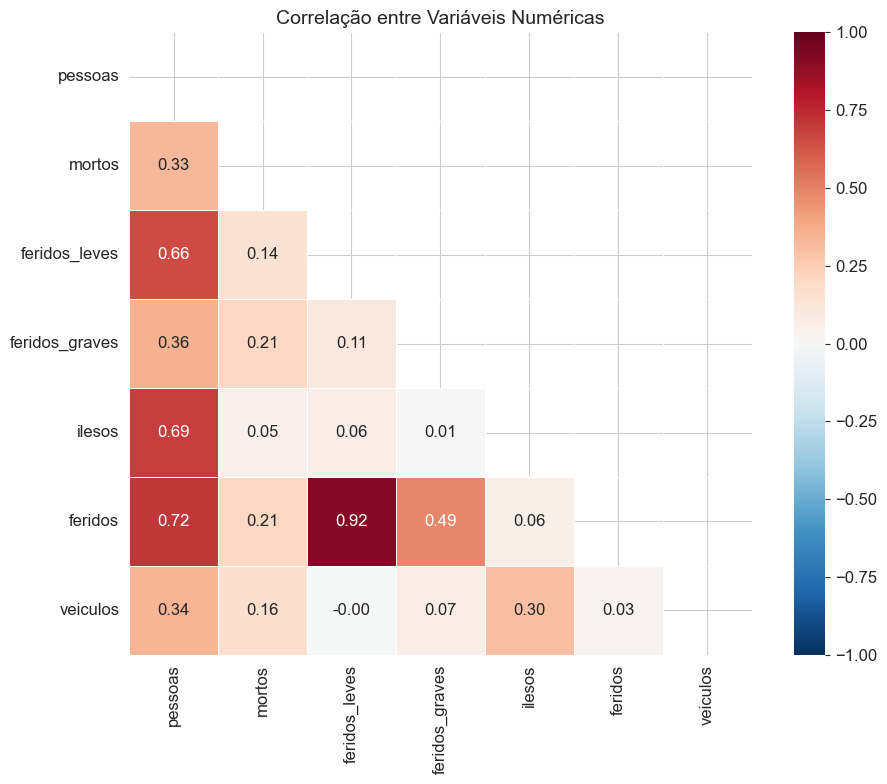

In [24]:
# 2.6.1 — Heatmap de correlação entre variáveis numéricas
cols_num = [c for c in COLUNAS_NUMERICAS if c in df.columns]
if len(cols_num) > 1:
    corr = df[cols_num].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, linewidths=0.5, square=True,
                vmin=-1, vmax=1)
    ax.set_title('Correlação entre Variáveis Numéricas')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlacao_numericas.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Poucas variáveis numéricas disponíveis para correlação.')

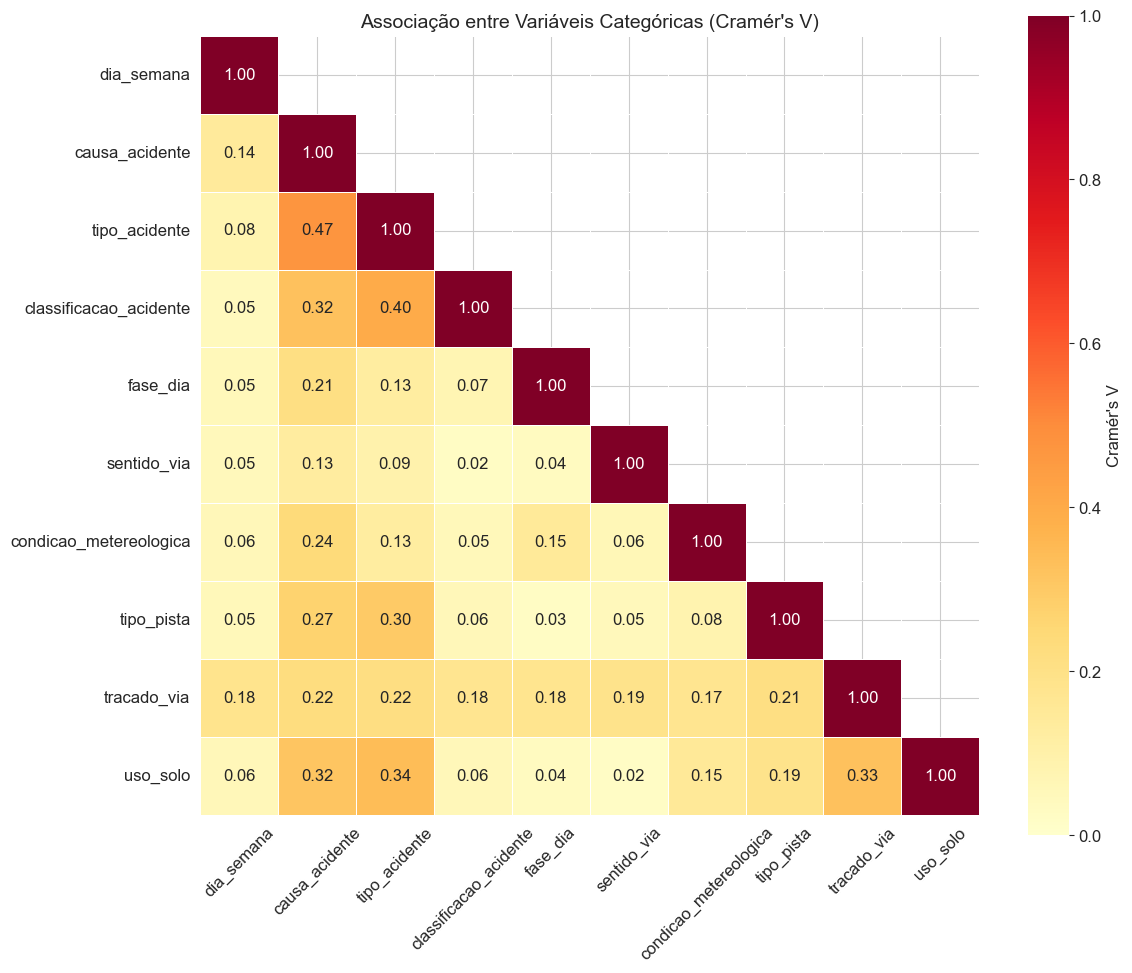


Pares com maior associação (Cramers V > 0.15):
  dia_semana <-> tracado_via: 0.183
  causa_acidente <-> tipo_acidente: 0.473
  causa_acidente <-> classificacao_acidente: 0.325
  causa_acidente <-> fase_dia: 0.213
  causa_acidente <-> condicao_metereologica: 0.241
  causa_acidente <-> tipo_pista: 0.270
  causa_acidente <-> tracado_via: 0.225
  causa_acidente <-> uso_solo: 0.315
  tipo_acidente <-> classificacao_acidente: 0.399
  tipo_acidente <-> tipo_pista: 0.301
  tipo_acidente <-> tracado_via: 0.218
  tipo_acidente <-> uso_solo: 0.342
  classificacao_acidente <-> tracado_via: 0.175
  fase_dia <-> tracado_via: 0.177
  sentido_via <-> tracado_via: 0.191
  condicao_metereologica <-> tracado_via: 0.174
  tipo_pista <-> tracado_via: 0.213
  tipo_pista <-> uso_solo: 0.189
  tracado_via <-> uso_solo: 0.325


In [25]:
# 2.6.2 — Cramér's V entre variáveis categóricas
def cramers_v(x, y):
    """
    Calcula o coeficiente de Cramér's V entre duas variáveis categóricas.
    Mede a associação entre variáveis categóricas (0 = sem associação, 1 = associação perfeita).
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape[0] - 1, confusion_matrix.shape[1] - 1)
    if min_dim == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))

# Calcular Cramér's V para todas as combinações
cols_cat = [c for c in COLUNAS_CATEGORICAS if c in df.columns]
n_cols = len(cols_cat)
cramers_matrix = pd.DataFrame(np.zeros((n_cols, n_cols)),
                              index=cols_cat, columns=cols_cat)

for i in range(n_cols):
    for j in range(i, n_cols):
        if i == j:
            cramers_matrix.iloc[i, j] = 1.0
        else:
            v = cramers_v(
                df[cols_cat[i]].fillna('N/A'),
                df[cols_cat[j]].fillna('N/A')
            )
            cramers_matrix.iloc[i, j] = v
            cramers_matrix.iloc[j, i] = v

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool), k=1)
sns.heatmap(cramers_matrix.astype(float), mask=mask, annot=True, fmt='.2f',
            cmap='YlOrRd', ax=ax, linewidths=0.5, square=True,
            vmin=0, vmax=1, cbar_kws={'label': "Cramér's V"})
ax.set_title("Associação entre Variáveis Categóricas (Cramér's V)")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cramers_v_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

# Listar pares com maior associação
print('\nPares com maior associação (Cramers V > 0.15):')
for i in range(n_cols):
    for j in range(i+1, n_cols):
        v = cramers_matrix.iloc[i, j]
        if v > 0.15:
            print(f'  {cols_cat[i]} <-> {cols_cat[j]}: {v:.3f}')

=== Associação de cada variável com classificacao_acidente ===
(Cramers V — quanto maior, mais associada à gravidade)



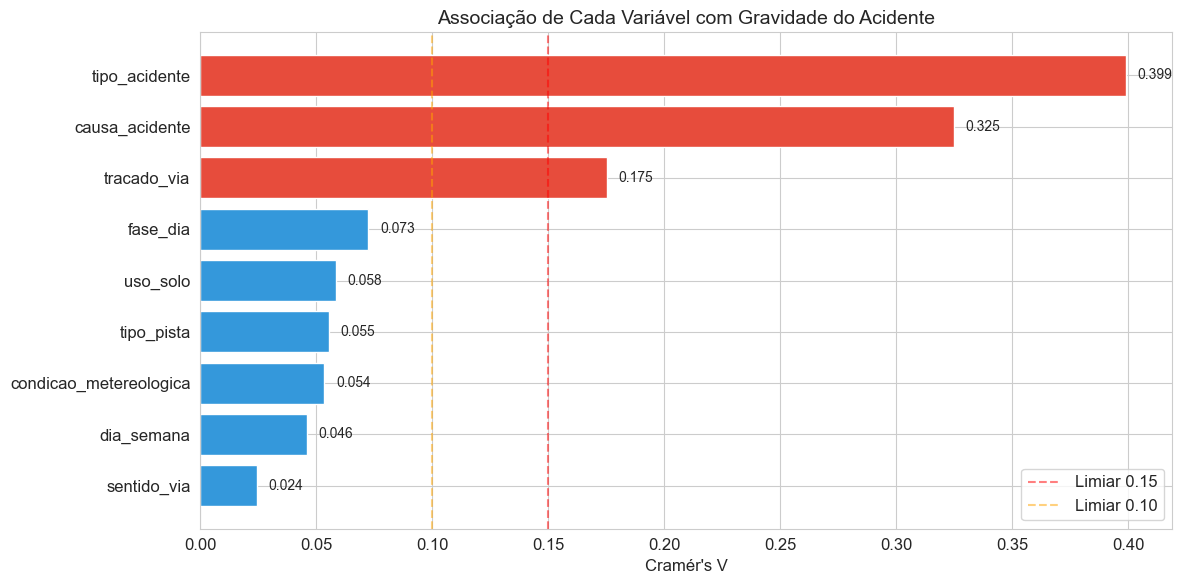

In [26]:
# 2.6.3 — Associação de cada categórica com a gravidade
print('=== Associação de cada variável com classificacao_acidente ===')
print('(Cramers V — quanto maior, mais associada à gravidade)\n')

assoc_gravidade = {}
for col in cols_cat:
    if col == 'classificacao_acidente':
        continue
    v = cramers_v(
        df[col].fillna('N/A'),
        df['classificacao_acidente'].fillna('Ignorado')
    )
    assoc_gravidade[col] = v

# Ordenar e exibir
assoc_series = pd.Series(assoc_gravidade).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
cores_bar = ['#e74c3c' if v > 0.15 else '#f39c12' if v > 0.10 else '#3498db'
             for v in assoc_series.values]
ax.barh(range(len(assoc_series)), assoc_series.values, color=cores_bar)
ax.set_yticks(range(len(assoc_series)))
ax.set_yticklabels(assoc_series.index)
ax.set_xlabel("Cramér's V")
ax.set_title("Associação de Cada Variável com Gravidade do Acidente")
ax.axvline(x=0.15, color='red', linestyle='--', alpha=0.5, label='Limiar 0.15')
ax.axvline(x=0.10, color='orange', linestyle='--', alpha=0.5, label='Limiar 0.10')
ax.legend()
ax.invert_yaxis()

for i, v in enumerate(assoc_series.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'associacao_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 2.7 Análise Complementar: Variáveis Numéricas por Gravidade

In [27]:
# Estatísticas numéricas por gravidade
cols_num_disp = [c for c in ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves',
                              'feridos', 'veiculos'] if c in df.columns]

df_stats = df.groupby(
    df['classificacao_acidente'].fillna('Ignorado')
)[cols_num_disp].agg(['mean', 'median', 'std', 'max']).round(2)

print('=== Estatísticas Numéricas por Gravidade ===')
df_stats

=== Estatísticas Numéricas por Gravidade ===


pessoas                   mortos                    \
                          mean median    std max   mean median    std max   
classificacao_acidente                                                      
Com Vítimas Fatais      4.6100 3.0000 7.4000  59 1.2700 1.0000 0.7200   6   
Com Vítimas Feridas     2.6200 2.0000 2.0400  40 0.0000 0.0000 0.0000   0   
Sem Vítimas             1.9700 2.0000 1.2300  11 0.0000 0.0000 0.0000   0   

                       feridos_leves                   feridos_graves         \
                                mean median    std max           mean median   
classificacao_acidente                                                         
Com Vítimas Fatais            0.9500 0.0000 4.2600  40         0.5200 0.0000   
Com Vítimas Feridas           1.1700 1.0000 1.2200  39         0.3100 0.0000   
Sem Vítimas                   0.0000 0.0000 0.0000   0         0.0000 0.0000   

                                  feridos                   veiculos         \
                          std max    mean median    std max     mean median   
classificacao_acidente                                                        
Com Vítimas Fatais     1.7800  23  1.4600 0.0000 5.3300  47   2.7000 2.0000   
Com Vítimas Feridas    0.6000   6  1.4800 1.0000 1.2000  40   1.9000 2.0000   
Sem Vítimas            0.0000   0  0.0000 0.0000 0.0000   0   1.7600 2.0000   

                                   
                          std max  
classificacao_acidente             
Com Vítimas Fatais     1.4300  10  
Com Vítimas Feridas    1.1000  14  
Sem Vítimas            1.0600  11

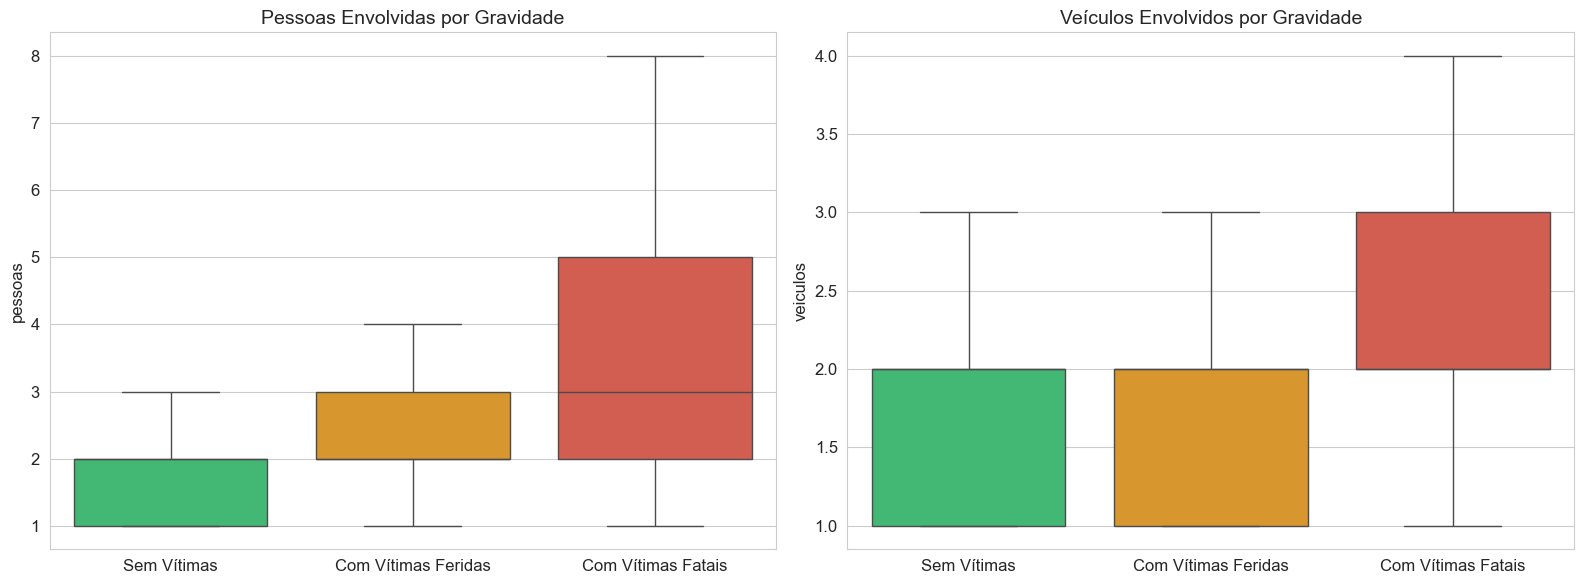

In [28]:
# Boxplots: pessoas e veículos envolvidos por gravidade
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df.copy()
df_plot['gravidade'] = df_plot['classificacao_acidente'].fillna('Ignorado')

if 'pessoas' in df.columns:
    ordem_grav = ['Sem Vítimas', 'Com Vítimas Feridas', 'Com Vítimas Fatais']
    ordem_grav = [g for g in ordem_grav if g in df_plot['gravidade'].values]
    palette_grav = [CORES_GRAVIDADE.get(g, '#95a5a6') for g in ordem_grav]

    sns.boxplot(data=df_plot[df_plot['gravidade'].isin(ordem_grav)],
                x='gravidade', y='pessoas', order=ordem_grav,
                palette=palette_grav, ax=axes[0], showfliers=False)
    axes[0].set_title('Pessoas Envolvidas por Gravidade')
    axes[0].set_xlabel('')

if 'veiculos' in df.columns:
    sns.boxplot(data=df_plot[df_plot['gravidade'].isin(ordem_grav)],
                x='gravidade', y='veiculos', order=ordem_grav,
                palette=palette_grav, ax=axes[1], showfliers=False)
    axes[1].set_title('Veículos Envolvidos por Gravidade')
    axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boxplot_numericas_gravidade.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 2.8 Insights Preliminares e Hipóteses

Esta seção consolida as principais observações da análise exploratória e formula hipóteses para a mineração de regras de associação.

### Qualidade dos Dados
- **Valores nulos**: documentar colunas com nulos e estratégia de tratamento
- **`classificacao_acidente`**: verificar presença de NA/Ignorado
- **`tracado_via`**: valores compostos com `;` precisarão de split na Fase 3
- **Categorias raras**: listar as que possuem < 1% e decidir agrupamento

### Padrões Observados
- Verificar se acidentes fatais concentram-se em determinados dias/fases
- Verificar se zona rural apresenta maior proporção de acidentes fatais
- Verificar quais causas/tipos têm maior associação com gravidade

### Hipóteses para Mineração
1. **H1**: Combinações de {Plena Noite, Pista Simples, Zona Rural} estão associadas a maior gravidade
2. **H2**: Finais de semana + Madrugada apresentam padrões distintos de causalidade
3. **H3**: Colisões frontais e atropelamentos têm lift alto com acidentes fatais
4. **H4**: Condições meteorológicas adversas (chuva) combinadas com tipo de pista influenciam gravidade
5. **H5**: Padrões de acidentes variam entre zonas urbanas e rurais

### Implicações para o FP-Growth
- O desbalanceamento da variável-alvo impactará o suporte mínimo
- Categorias raras podem não gerar regras significativas
- A discretização do horário em faixas será importante para gerar itens úteis

In [29]:
# Resumo final da EDA
print('=' * 60)
print('RESUMO DA FASE 2 — ANALISE EXPLORATORIA')
print('=' * 60)
print(f'\nDataset: {ACTIVE_DATASET} ({FILTRO_UF})')
print(f'Registros: {len(df):,}')
print(f'Colunas: {df.shape[1]}')

# Gravidade
grav = df['classificacao_acidente'].fillna('Ignorado').value_counts(normalize=True) * 100
print(f'\nDistribuicao de gravidade:')
for cat, pct in grav.items():
    print(f'  {cat}: {pct:.1f}%')

# Top 3 variáveis mais associadas à gravidade
print(f'\nTop 3 variaveis mais associadas a gravidade (Cramers V):')
for col, v in assoc_series.head(3).items():
    print(f'  {col}: {v:.3f}')

# Visualizações produzidas
from pathlib import Path
figs_salvas = list(OUTPUT_DIR.glob('*.png'))
print(f'\nVisualizacoes salvas: {len(figs_salvas)}')
for f in sorted(figs_salvas):
    print(f'  {f.name}')

print(f'\n-> Proximo passo: Fase 3 — Preparacao dos Dados')

RESUMO DA FASE 2 — ANALISE EXPLORATORIA

Dataset: por_ocorrencia (MG)
Registros: 2,985
Colunas: 36

Distribuicao de gravidade:
  Com Vítimas Feridas: 79.3%
  Sem Vítimas: 13.6%
  Com Vítimas Fatais: 7.1%

Top 3 variaveis mais associadas a gravidade (Cramers V):
  tipo_acidente: 0.399
  causa_acidente: 0.325
  tracado_via: 0.175

Visualizacoes salvas: 17
  acidentes_dia_semana.png
  acidentes_fase_dia.png
  acidentes_mes.png
  associacao_gravidade.png
  boxplot_numericas_gravidade.png
  correlacao_numericas.png
  cramers_v_categoricas.png
  distribuicao_gravidade.png
  distribuicao_horaria.png
  heatmap_temporal.png
  meteo_pista_gravidade.png
  serie_temporal_semanal.png
  tipos_acidente_gravidade.png
  top_brs.png
  top_causas_gravidade.png
  top_municipios.png
  uso_solo.png

-> Proximo passo: Fase 3 — Preparacao dos Dados
